In [703]:
!pip install requests beautifulsoup4
!pip install xlrd

In [704]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import numpy as np

In [705]:
url = 'https://www.princetonreview.com/college-advice/sat-score-by-state'
headers = {'User-Agent': 'Mozilla/5.0'}

response = requests.get(url, headers=headers)
soup = BeautifulSoup(response.content, 'html.parser')

In [706]:
rows = soup.find_all('tr')

data = []

for row in rows:
    cells = row.find_all(['th', 'td'])
    cell_text = [cell.get_text(strip=True) for cell in cells]
    if cell_text:
        data.append(cell_text)


In [707]:
rows = soup.find_all('tr')

data = []

for row in rows:
    cells = row.find_all(['th', 'td'])
    cell_text = [cell.get_text(strip=True) for cell in cells]
    if cell_text:
        data.append(cell_text)


In [708]:
#print (data[0])   Make sure first line is table column names

headers = data[0]
rows = data[1:]

SAT = pd.DataFrame(rows, columns=headers)

print(SAT.head())


        State % of students taking the SAT # of Test Takers  \
0     Alabama                           3%            1,517   
1      Alaska                          32%            2,625   
2     Arizona                          10%            8,367   
3    Arkansas                           2%              733   
4  California                          24%          120,205   

  Average Composite Score  
0                    1160  
1                    1080  
2                    1190  
3                    1190  
4                    1090  


In [709]:
print(SAT.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51 entries, 0 to 50
Data columns (total 4 columns):
 #   Column                        Non-Null Count  Dtype 
---  ------                        --------------  ----- 
 0   State                         51 non-null     object
 1   % of students taking the SAT  51 non-null     object
 2   # of Test Takers              51 non-null     object
 3   Average Composite Score       51 non-null     object
dtypes: object(4)
memory usage: 1.7+ KB
None


In [710]:
print(SAT.describe())

          State % of students taking the SAT # of Test Takers  \
count        51                           51               51   
unique       51                           34               51   
top     Alabama                           2%            1,517   
freq          1                            7                1   

       Average Composite Score  
count                       51  
unique                      26  
top                        970  
freq                         5  


In [711]:
print(SAT.isnull())

    State  % of students taking the SAT  # of Test Takers  \
0   False                         False             False   
1   False                         False             False   
2   False                         False             False   
3   False                         False             False   
4   False                         False             False   
5   False                         False             False   
6   False                         False             False   
7   False                         False             False   
8   False                         False             False   
9   False                         False             False   
10  False                         False             False   
11  False                         False             False   
12  False                         False             False   
13  False                         False             False   
14  False                         False             False   
15  False               

In [712]:
print(SAT.duplicated().sum())

0


In [713]:
print(SAT.dtypes)

State                           object
% of students taking the SAT    object
# of Test Takers                object
Average Composite Score         object
dtype: object


In [714]:
print  (SAT['% of students taking the SAT'].value_counts())

SAT['% of students taking the SAT'] = SAT['% of students taking the SAT'].str.replace('%','', regex=False)
SAT['% of students taking the SAT'] = SAT['% of students taking the SAT'].astype(int)

print  (SAT['% of students taking the SAT'].value_counts())


% of students taking the SAT
2%      7
1%      5
100%    3
3%      3
51%     2
96%     2
4%      2
24%     1
82%     1
37%     1
43%     1
73%     1
99%     1
46%     1
23%     1
9%      1
21%     1
20%     1
61%     1
66%     1
6%      1
90%     1
32%     1
55%     1
70%     1
38%     1
76%     1
27%     1
56%     1
95%     1
10%     1
97%     1
98%     1
89%     1
Name: count, dtype: int64
% of students taking the SAT
2      7
1      5
100    3
3      3
51     2
96     2
4      2
24     1
82     1
37     1
43     1
73     1
99     1
46     1
23     1
9      1
21     1
20     1
61     1
66     1
6      1
90     1
32     1
55     1
70     1
38     1
76     1
27     1
56     1
95     1
10     1
97     1
98     1
89     1
Name: count, dtype: int64


In [715]:
#SAT['% of students taking the SAT'] = SAT['% of students taking the SAT'].astype(float)    This one has a problem
SAT['# of Test Takers'] = SAT['# of Test Takers'].astype(str)
SAT['Average Composite Score'] = SAT['Average Composite Score'].astype(int)

print(SAT.dtypes)

State                           object
% of students taking the SAT     int32
# of Test Takers                object
Average Composite Score          int32
dtype: object


In [716]:
print(SAT['State'].value_counts())
print(SAT['Average Composite Score'].value_counts())
print(SAT['# of Test Takers'].value_counts())

State
Alabama                 1
Pennsylvania            1
Nevada                  1
New Hampshire           1
New Jersey              1
New Mexico              1
New York                1
North Carolina          1
North Dakota            1
Ohio                    1
Oklahoma                1
Oregon                  1
Rhode Island            1
Montana                 1
South Carolina          1
South Dakota            1
Tennessee               1
Texas                   1
Utah                    1
Vermont                 1
Virginia                1
Washington              1
West Virginia           1
Wisconsin               1
Nebraska                1
Missouri                1
Alaska                  1
Idaho                   1
Arizona                 1
Arkansas                1
California              1
Colorado                1
Connecticut             1
Delaware                1
District of Columbia    1
Florida                 1
Georgia                 1
Hawaii                  1
Illino

In [717]:
SAT['# of Test Takers'] = SAT['# of Test Takers'].str.replace(',','', regex=False)
SAT['# of Test Takers'] = SAT['# of Test Takers'].astype(int)


print(SAT['# of Test Takers'].value_counts())

# of Test Takers
1517      1
67012     1
2028      1
12327     1
77320     1
23071     1
127993    1
23495     1
58        1
27389     1
4339      1
9847      1
11275     1
426       1
28563     1
150       1
3325      1
291694    1
771       1
2720      1
49631     1
29189     1
15683     1
1301      1
320       1
2190      1
2625      1
17603     1
8367      1
733       1
120205    1
58078     1
42020     1
10880     1
6535      1
229784    1
69136     1
4202      1
141846    1
382       1
80008     1
916       1
734       1
962       1
1117      1
5545      1
52851     1
43398     1
103396    1
2146      1
84        1
Name: count, dtype: int64


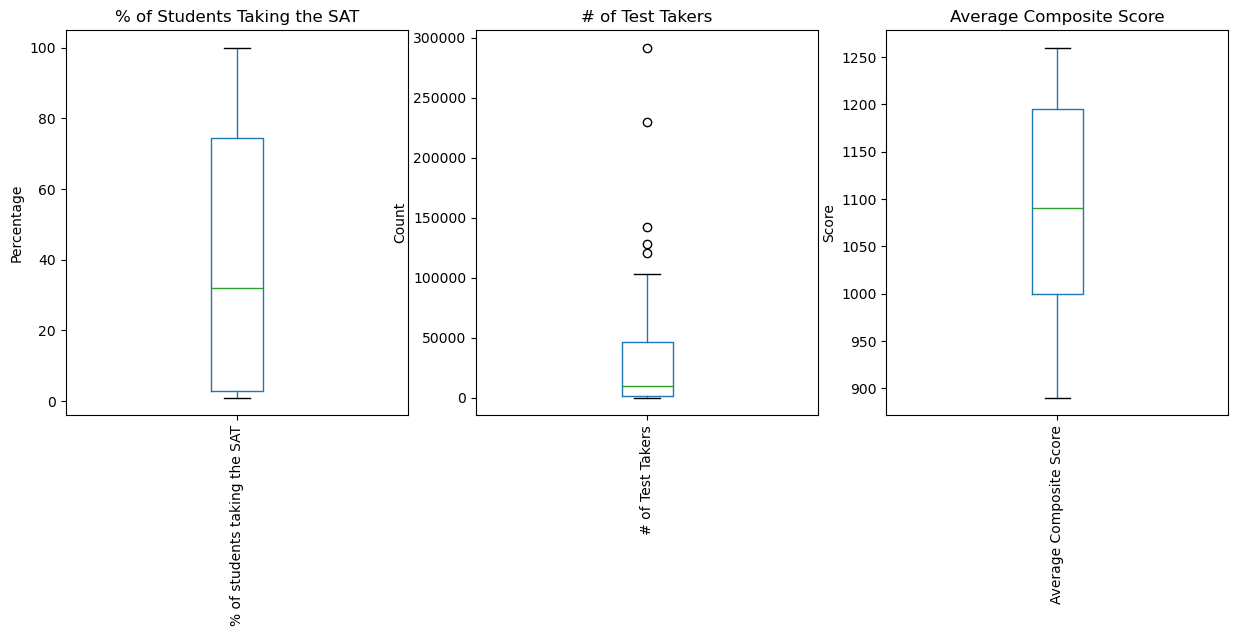

In [718]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

#'% of students taking the SAT'
SAT.boxplot(column='% of students taking the SAT', ax=ax1, grid=False)
ax1.set_title('% of Students Taking the SAT')
ax1.set_ylabel('Percentage')
ax1.tick_params(axis='x', rotation=90)

#'# of Test Takers'
SAT.boxplot(column='# of Test Takers', ax=ax2, grid=False)
ax2.set_title('# of Test Takers')
ax2.set_ylabel('Count')
ax2.tick_params(axis='x', rotation=90)

#'Average Composite Score'
SAT.boxplot(column='Average Composite Score', ax=ax3, grid=False)
ax3.set_title('Average Composite Score')
ax3.set_ylabel('Score')
ax3.tick_params(axis='x', rotation=90)

In [719]:
print(SAT.sort_values(by='# of Test Takers', ascending=False))

                   State  % of students taking the SAT  # of Test Takers  \
43                 Texas                            73            291694   
9                Florida                            95            229784   
13              Illinois                            96            141846   
32              New York                            61            127993   
4             California                            24            120205   
22              Michigan                            96            103396   
14               Indiana                           100             80008   
30            New Jersey                            66             77320   
10               Georgia                            56             69136   
38          Pennsylvania                            46             67012   
5               Colorado                            90             58078   
20              Maryland                            70             52851   
46          

In [720]:
###############################################

In [721]:
url = 'https://www.act.org/content/act/en/products-and-services/the-act/scores/average-act-test-scores-by-state.html'
headers = {'User-Agent': 'Mozilla/5.0'}

response = requests.get(url, headers=headers)
soup = BeautifulSoup(response.content, 'html.parser')

In [722]:
rows = soup.find_all('tr')

data = []

for row in rows:
    cells = row.find_all(['th', 'td'])
    cell_text = [cell.get_text(strip=True) for cell in cells]
    if cell_text:
        data.append(cell_text)

In [723]:
#print (data[0])   Make sure first line is table column names

headers = data[0]
rows = data[1:]

ACT = pd.DataFrame(rows, columns=headers)

print(ACT.head(2))


     State Estimated % of Grads Tested Average Composite Score  \
0  Alabama                         100                    18.0   
1  Arizona                         100                    17.7   

  % Meeting English Benchmark (18) % Meeting Math Benchmark (22)  \
0                               43                            18   
1                               41                            22   

  % Meeting Reading Benchmark (22) % Meeting Science Benchmark (23)  
0                               30                               21  
1                               28                               19  


In [724]:
print(ACT.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 7 columns):
 #   Column                            Non-Null Count  Dtype 
---  ------                            --------------  ----- 
 0   State                             52 non-null     object
 1   Estimated % of Grads Tested       52 non-null     object
 2   Average Composite Score           52 non-null     object
 3   % Meeting English Benchmark (18)  52 non-null     object
 4   % Meeting Math Benchmark (22)     52 non-null     object
 5   % Meeting Reading Benchmark (22)  52 non-null     object
 6   % Meeting Science Benchmark (23)  52 non-null     object
dtypes: object(7)
memory usage: 3.0+ KB
None


In [725]:
print(ACT.describe())

          State Estimated % of Grads Tested Average Composite Score  \
count        52                          52                      52   
unique       52                          30                      36   
top     Alabama                         100                    19.4   
freq          1                           9                       3   

       % Meeting English Benchmark (18) % Meeting Math Benchmark (22)  \
count                                52                            52   
unique                               31                            35   
top                                  85                            30   
freq                                  5                             4   

       % Meeting Reading Benchmark (22) % Meeting Science Benchmark (23)  
count                                52                               52  
unique                               34                               33  
top                                  36              

In [726]:
print(ACT.isnull())

    State  Estimated % of Grads Tested  Average Composite Score  \
0   False                        False                    False   
1   False                        False                    False   
2   False                        False                    False   
3   False                        False                    False   
4   False                        False                    False   
5   False                        False                    False   
6   False                        False                    False   
7   False                        False                    False   
8   False                        False                    False   
9   False                        False                    False   
10  False                        False                    False   
11  False                        False                    False   
12  False                        False                    False   
13  False                        False                    Fals

In [727]:
print(ACT.duplicated().sum())

0


In [728]:
print(ACT.dtypes)

State                               object
Estimated % of Grads Tested         object
Average Composite Score             object
% Meeting English Benchmark (18)    object
% Meeting Math Benchmark (22)       object
% Meeting Reading Benchmark (22)    object
% Meeting Science Benchmark (23)    object
dtype: object


In [729]:
ACT['Estimated % of Grads Tested'] = ACT['Estimated % of Grads Tested'].astype(float)
ACT['Average Composite Score'] = ACT['Average Composite Score'].astype(float)
ACT['% Meeting English Benchmark (18)'] = ACT['% Meeting English Benchmark (18)'].astype(float)
ACT['% Meeting Math Benchmark (22)'] = ACT['% Meeting Math Benchmark (22)'].astype(float)
ACT['% Meeting Reading Benchmark (22)'] = ACT['% Meeting Reading Benchmark (22)'].astype(float)
ACT['% Meeting Science Benchmark (23)'] = ACT['% Meeting Science Benchmark (23)'].astype(float)

print(ACT.dtypes)

State                                object
Estimated % of Grads Tested         float64
Average Composite Score             float64
% Meeting English Benchmark (18)    float64
% Meeting Math Benchmark (22)       float64
% Meeting Reading Benchmark (22)    float64
% Meeting Science Benchmark (23)    float64
dtype: object


In [730]:
print(ACT['State'].value_counts())

State
Alabama                 1
Arizona                 1
District of Columbia    1
Illinois                1
Alaska                  1
Oregon                  1
New Mexico              1
Idaho                   1
New Jersey              1
Colorado                1
Connecticut             1
New York                1
Virginia                1
Indiana                 1
Massachusetts           1
Maryland                1
Michigan                1
Vermont                 1
Pennsylvania            1
Washington              1
Delaware                1
New Hampshire           1
Rhode Island            1
California              1
Maine                   1
West Virginia           1
Texas                   1
Georgia                 1
Wisconsin               1
Kentucky                1
Louisiana               1
Mississippi             1
Nevada                  1
Oklahoma                1
Tennessee               1
Wyoming                 1
Montana                 1
Arkansas                1
Nebras

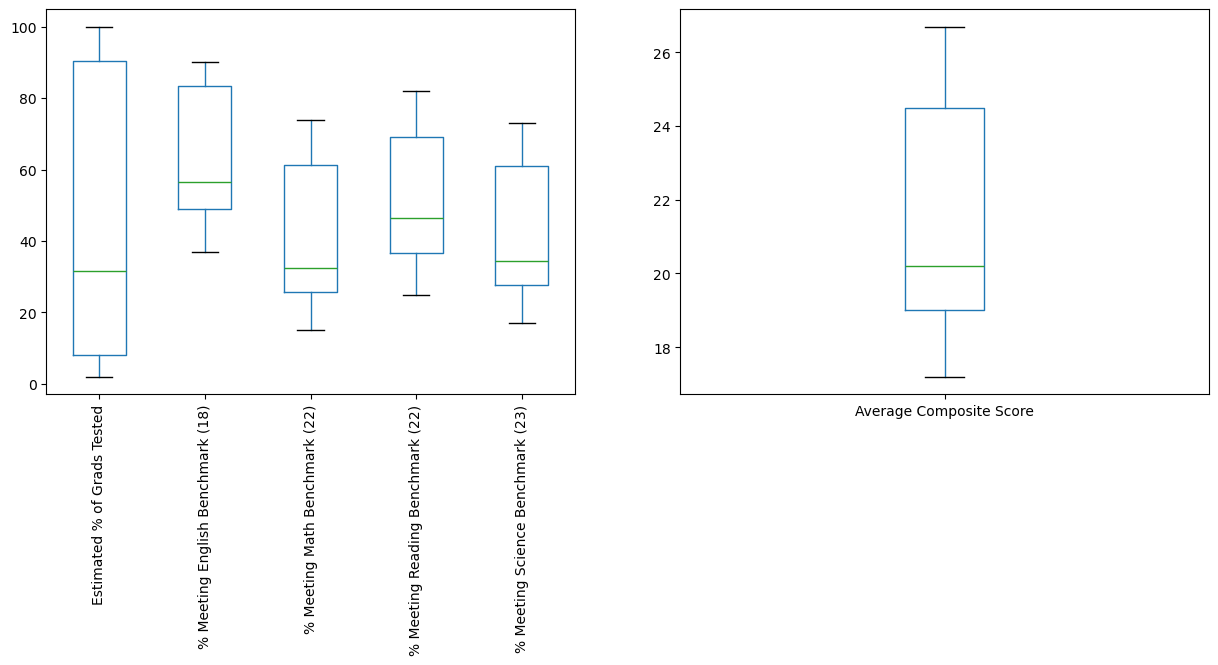

In [731]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

plt.xticks(rotation = 75)

ACT.boxplot(column=['Estimated % of Grads Tested', 
                    '% Meeting English Benchmark (18)',
                    '% Meeting Math Benchmark (22)',
                    '% Meeting Reading Benchmark (22)',
                    '% Meeting Science Benchmark (23)'],
            rot=90,
            ax=ax1,
           grid=False)

ACT.boxplot(column='Average Composite Score', ax=ax2, grid=False)

plt.show()

In [732]:
###############################################

In [733]:
# Reading directly from the URL looking for <table> tags
url = 'https://nces.ed.gov/programs/digest/d23/tables/dt23_219.46.asp'

ACGR = tables[2]
ACGR.head(10)

,0,1,2,3,4,5,6,7,8,9,...,37,38,39,40,41,42,43,44,45,46
0,State or jurisdiction,"Total, ACGR for all students","Total, ACGR for all students","Total, ACGR for all students","Total, ACGR for all students","Total, ACGR for all students","Total, ACGR for all students","Total, ACGR for all students","Total, ACGR for all students","Total, ACGR for all students",...,ACGR for students with selected characteristic...,ACGR for students with selected characteristic...,ACGR for students with selected characteristic...,ACGR for students with selected characteristic...,ACGR for students with selected characteristic...,ACGR for students with selected characteristic...,ACGR for students with selected characteristic...,ACGR for students with selected characteristic...,ACGR for students with selected characteristic...,ACGR for students with selected characteristic...
1,State or jurisdiction,2011- 12,2011- 12,2012- 13,2012- 13,2013- 14,2014- 15,2015- 16,2016- 17,2017- 18,...,Race/ethnicity,Race/ethnicity,Race/ethnicity,Race/ethnicity,Students with disabil- ities2,English learner3,English learner3,Economi- cally disadvan- taged4,Homeless enrolled,Foster care
2,State or jurisdiction,2011- 12,2011- 12,2012- 13,2012- 13,2013- 14,2014- 15,2015- 16,2016- 17,2017- 18,...,Black,Hispanic,White,Two or more races,Students with disabil- ities2,English learner3,English learner3,Economi- cally disadvan- taged4,Homeless enrolled,Foster care
3,State or jurisdiction,2011- 12,2011- 12,2012- 13,2012- 13,2013- 14,2014- 15,2015- 16,2016- 17,2017- 18,...,Black,Hispanic,White,Two or more races,Students with disabil- ities2,English learner3,English learner3,Economi- cally disadvan- taged4,Homeless enrolled,Foster care
4,1,2,2,3,3,4,5,6,7,8,...,30,31,32,33,34,35,35,36,37,38
5,United States,80,6,81,7,82,83,84,85,85,...,81,83,90,---,71,72,NaN,81,68,---
6,Alabama12,75,NaN,80,NaN,86,89,87,89,90,...,85,84,90,90,74,68,NaN,83,76,64
7,Alaska,70,NaN,72,NaN,71,76,76,78,79,...,74,77,84,75,61,65,NaN,70,59,53
8,Arizona,76,NaN,75,NaN,76,77,80,78,79,...,72,73,83,78,67,60,NaN,73,48,39
9,Arkansas,84,NaN,85,NaN,87,85,87,88,89,...,85,87,90,86,83,82,NaN,85,78,64


In [734]:
ACGR = ACGR.iloc[3:]   #shaving off unneeded rows
ACGR = ACGR.drop(ACGR.index[1])
ACGR.head(10)

,0,1,2,3,4,5,6,7,8,9,...,37,38,39,40,41,42,43,44,45,46
3,State or jurisdiction,2011- 12,2011- 12,2012- 13,2012- 13,2013- 14,2014- 15,2015- 16,2016- 17,2017- 18,...,Black,Hispanic,White,Two or more races,Students with disabil- ities2,English learner3,English learner3,Economi- cally disadvan- taged4,Homeless enrolled,Foster care
5,United States,80,6,81,7,82,83,84,85,85,...,81,83,90,---,71,72,NaN,81,68,---
6,Alabama12,75,NaN,80,NaN,86,89,87,89,90,...,85,84,90,90,74,68,NaN,83,76,64
7,Alaska,70,NaN,72,NaN,71,76,76,78,79,...,74,77,84,75,61,65,NaN,70,59,53
8,Arizona,76,NaN,75,NaN,76,77,80,78,79,...,72,73,83,78,67,60,NaN,73,48,39
9,Arkansas,84,NaN,85,NaN,87,85,87,88,89,...,85,87,90,86,83,82,NaN,85,78,64
10,California,79,NaN,80,NaN,81,82,83,83,83,...,79,85,91,87,74,72,NaN,85,73,61
11,Colorado,75,NaN,77,NaN,77,77,79,79,81,...,77,75,87,81,68,69,NaN,72,55,30
12,Connecticut,85,NaN,86,NaN,87,87,87,88,88,...,82,81,94,89,70,70,NaN,82,67,57
13,Delaware,80,NaN,80,NaN,87,86,86,87,87,...,85,82,92,88,72,69,NaN,81,70,55


In [735]:
ACGR = ACGR.iloc[:, :17]  #shaving off extra columns (these deal with minority status, language, homelessness, etc.)
ACGR.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16
3,State or jurisdiction,2011- 12,2011- 12,2012- 13,2012- 13,2013- 14,2014- 15,2015- 16,2016- 17,2017- 18,2018- 19,2019- 20,2019- 20,2020- 21,2020- 21,2021- 22,2021- 22
5,United States,80,6,81,7,82,83,84,85,85,86,87,8,86,9,87,10
6,Alabama12,75,NaN,80,NaN,86,89,87,89,90,92,91,NaN,91,NaN,88,NaN
7,Alaska,70,NaN,72,NaN,71,76,76,78,79,80,79,NaN,78,NaN,78,NaN
8,Arizona,76,NaN,75,NaN,76,77,80,78,79,78,77,NaN,76,NaN,77,NaN


In [736]:
ACGR.columns = ACGR.iloc[0]    # Setting first row as column names

ACGR = ACGR[1:].reset_index(drop=True)

print(ACGR.head())

3 State or jurisdiction 2011- 12 2011- 12 2012- 13 2012- 13 2013- 14 2014- 15  \
0         United States       80        6       81        7       82       83   
1             Alabama12       75      NaN       80      NaN       86       89   
2                Alaska       70      NaN       72      NaN       71       76   
3               Arizona       76      NaN       75      NaN       76       77   
4              Arkansas       84      NaN       85      NaN       87       85   

3 2015- 16 2016- 17 2017- 18 2018- 19 2019- 20 2019- 20 2020- 21 2020- 21  \
0       84       85       85       86       87        8       86        9   
1       87       89       90       92       91      NaN       91      NaN   
2       76       78       79       80       79      NaN       78      NaN   
3       80       78       79       78       77      NaN       76      NaN   
4       87       88       89       88       89      NaN       88      NaN   

3 2021- 22 2021- 22  
0       87       10  
1     

In [737]:
ACGR.columns = ACGR.columns.str.replace(' ', '', regex=False)   #removing the extra space in the year span
print(ACGR.head())

3 Stateorjurisdiction 2011-12 2011-12 2012-13 2012-13 2013-14 2014-15 2015-16  \
0       United States      80       6      81       7      82      83      84   
1           Alabama12      75     NaN      80     NaN      86      89      87   
2              Alaska      70     NaN      72     NaN      71      76      76   
3             Arizona      76     NaN      75     NaN      76      77      80   
4            Arkansas      84     NaN      85     NaN      87      85      87   

3 2016-17 2017-18 2018-19 2019-20 2019-20 2020-21 2020-21 2021-22 2021-22  
0      85      85      86      87       8      86       9      87      10  
1      89      90      92      91     NaN      91     NaN      88     NaN  
2      78      79      80      79     NaN      78     NaN      78     NaN  
3      78      79      78      77     NaN      76     NaN      77     NaN  
4      88      89      88      89     NaN      88     NaN      88     NaN  


In [738]:
ACGR = ACGR[:-20]     #the last 20 rows had extra stuff, legal, footnotes, and other non-state jurisdictions

In [739]:
print(ACGR.head())

3 Stateorjurisdiction 2011-12 2011-12 2012-13 2012-13 2013-14 2014-15 2015-16  \
0       United States      80       6      81       7      82      83      84   
1           Alabama12      75     NaN      80     NaN      86      89      87   
2              Alaska      70     NaN      72     NaN      71      76      76   
3             Arizona      76     NaN      75     NaN      76      77      80   
4            Arkansas      84     NaN      85     NaN      87      85      87   

3 2016-17 2017-18 2018-19 2019-20 2019-20 2020-21 2020-21 2021-22 2021-22  
0      85      85      86      87       8      86       9      87      10  
1      89      90      92      91     NaN      91     NaN      88     NaN  
2      78      79      80      79     NaN      78     NaN      78     NaN  
3      78      79      78      77     NaN      76     NaN      77     NaN  
4      88      89      88      89     NaN      88     NaN      88     NaN  


In [740]:
ACGR = ACGR.replace("Alabama12", "Alabama")
ACGR = ACGR.rename(columns={'Stateorjurisdiction': 'State/Jurisdiction'})
ACGR.drop(index=0, inplace=True)
print(ACGR.head())

3 State/Jurisdiction 2011-12 2011-12 2012-13 2012-13 2013-14 2014-15 2015-16  \
1            Alabama      75     NaN      80     NaN      86      89      87   
2             Alaska      70     NaN      72     NaN      71      76      76   
3            Arizona      76     NaN      75     NaN      76      77      80   
4           Arkansas      84     NaN      85     NaN      87      85      87   
5         California      79     NaN      80     NaN      81      82      83   

3 2016-17 2017-18 2018-19 2019-20 2019-20 2020-21 2020-21 2021-22 2021-22  
1      89      90      92      91     NaN      91     NaN      88     NaN  
2      78      79      80      79     NaN      78     NaN      78     NaN  
3      78      79      78      77     NaN      76     NaN      77     NaN  
4      88      89      88      89     NaN      88     NaN      88     NaN  
5      83      83      85      84     NaN      84     NaN      87     NaN  


In [741]:
print(ACGR.isna().sum())
ACGR.dropna(axis=1, inplace=True)
print(ACGR.isna().sum())

3
State/Jurisdiction     0
2011-12                0
2011-12               51
2012-13                0
2012-13               51
2013-14                0
2014-15                0
2015-16                0
2016-17                0
2017-18                0
2018-19                0
2019-20                0
2019-20               51
2020-21                0
2020-21               51
2021-22                0
2021-22               51
dtype: int64
3
State/Jurisdiction    0
2011-12               0
2012-13               0
2013-14               0
2014-15               0
2015-16               0
2016-17               0
2017-18               0
2018-19               0
2019-20               0
2020-21               0
2021-22               0
dtype: int64


In [742]:
print(ACGR.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51 entries, 1 to 51
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   State/Jurisdiction  51 non-null     object
 1   2011-12             51 non-null     object
 2   2012-13             51 non-null     object
 3   2013-14             51 non-null     object
 4   2014-15             51 non-null     object
 5   2015-16             51 non-null     object
 6   2016-17             51 non-null     object
 7   2017-18             51 non-null     object
 8   2018-19             51 non-null     object
 9   2019-20             51 non-null     object
 10  2020-21             51 non-null     object
 11  2021-22             51 non-null     object
dtypes: object(12)
memory usage: 4.9+ KB
None


In [743]:
print (ACGR.describe())

3      State/Jurisdiction 2011-12 2012-13 2013-14 2014-15 2015-16 2016-17  \
count                  51      51      51      51      51      51      51   
unique                 51      21      22      23      19      18      16   
top               Alabama      75      86      87      88      87      87   
freq                    1       5       7       7       7       6       8   

3      2017-18 2018-19 2019-20 2020-21 2021-22  
count       51      51      51      51      51  
unique      14      16      16      18      16  
top         87      87      84      90      90  
freq         7       9       7       8       7  


In [744]:
print (ACGR.isnull().sum())

3
State/Jurisdiction    0
2011-12               0
2012-13               0
2013-14               0
2014-15               0
2015-16               0
2016-17               0
2017-18               0
2018-19               0
2019-20               0
2020-21               0
2021-22               0
dtype: int64


In [745]:
ACGR = ACGR.set_index(ACGR.columns[0])
print(ACGR)

3                    2011-12 2012-13 2013-14 2014-15 2015-16 2016-17 2017-18  \
State/Jurisdiction                                                             
Alabama                   75      80      86      89      87      89      90   
Alaska                    70      72      71      76      76      78      79   
Arizona                   76      75      76      77      80      78      79   
Arkansas                  84      85      87      85      87      88      89   
California                79      80      81      82      83      83      83   
Colorado                  75      77      77      77      79      79      81   
Connecticut               85      86      87      87      87      88      88   
Delaware                  80      80      87      86      86      87      87   
District of Columbia      59      62      61      69      69      73      69   
Florida                   75      76      76      78      81      82      86   
Georgia                   70      72    

In [746]:
import re
#This is to get rid of all the odd symbols and hyphens in the data
def keep_alphanum(val):
    if pd.isna(val):
        return np.nan
    if isinstance(val, str):
        return val if re.fullmatch(r'[A-Za-z0-9]+', val) else np.nan
    if isinstance(val, (int, float)):
        return val
    return np.nan

ACGR = ACGR.applymap(keep_alphanum)
print(ACGR)

3                    2011-12 2012-13 2013-14 2014-15 2015-16 2016-17 2017-18  \
State/Jurisdiction                                                             
Alabama                   75      80      86      89      87      89      90   
Alaska                    70      72      71      76      76      78      79   
Arizona                   76      75      76      77      80      78      79   
Arkansas                  84      85      87      85      87      88      89   
California                79      80      81      82      83      83      83   
Colorado                  75      77      77      77      79      79      81   
Connecticut               85      86      87      87      87      88      88   
Delaware                  80      80      87      86      86      87      87   
District of Columbia      59      62      61      69      69      73      69   
Florida                   75      76      76      78      81      82      86   
Georgia                   70      72    

C:\Users\emcdo\AppData\Local\Temp\ipykernel_30952\1555139069.py:12: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ACGR = ACGR.applymap(keep_alphanum)


In [747]:
ACGR = ACGR.apply(pd.to_numeric, errors='coerce')
ACGR = ACGR.apply(lambda row: row.fillna(row.mean()), axis=1)
ACGR = ACGR.round().astype(int)
print(ACGR.info())

<class 'pandas.core.frame.DataFrame'>
Index: 51 entries, Alabama to Wyoming
Data columns (total 11 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   2011-12  51 non-null     int32
 1   2012-13  51 non-null     int32
 2   2013-14  51 non-null     int32
 3   2014-15  51 non-null     int32
 4   2015-16  51 non-null     int32
 5   2016-17  51 non-null     int32
 6   2017-18  51 non-null     int32
 7   2018-19  51 non-null     int32
 8   2019-20  51 non-null     int32
 9   2020-21  51 non-null     int32
 10  2021-22  51 non-null     int32
dtypes: int32(11)
memory usage: 2.6+ KB
None


In [748]:
print(ACGR)

3                     2011-12  2012-13  2013-14  2014-15  2015-16  2016-17  \
State/Jurisdiction                                                           
Alabama                    75       80       86       89       87       89   
Alaska                     70       72       71       76       76       78   
Arizona                    76       75       76       77       80       78   
Arkansas                   84       85       87       85       87       88   
California                 79       80       81       82       83       83   
Colorado                   75       77       77       77       79       79   
Connecticut                85       86       87       87       87       88   
Delaware                   80       80       87       86       86       87   
District of Columbia       59       62       61       69       69       73   
Florida                    75       76       76       78       81       82   
Georgia                    70       72       73       79       7

In [749]:
###############################################

In [750]:
ACGR.columns.name = "Year"
ACGR.index.name = "State"

In [751]:
#ACGR - Adjusted Cohort Graduation Rate
#ACT - ACT Scores
#SAT - SAT Scores

In [752]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
ACGR_scaled = pd.DataFrame(scaler.fit_transform(ACGR), columns=ACGR.columns, index=ACGR.index)

In [753]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(ACGR_scaled, test_size=0.2)

In [754]:
#I don't think scaling the data would be necessary, given how uniform it is, but that seems to be all that was necessary for this assignment.

In [755]:
#I spent a LOT of time scraping and cleaning data because all of this will be used on my major capstone project.

In [756]:
###############################################             ARIMA Model

In [757]:
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt

In [758]:
#Choosing my home state
series = ACGR.loc['Idaho'].dropna()

In [759]:
model = ARIMA(series, order=(1,1,1))
model_fit = model.fit()

print(model_fit.summary())

C:\Users\emcdo\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\emcdo\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\emcdo\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                  Idaho   No. Observations:                   11
Model:                 ARIMA(1, 1, 1)   Log Likelihood                 -16.597
Date:                Tue, 13 May 2025   AIC                             39.194
Time:                        11:12:30   BIC                             40.102
Sample:                             0   HQIC                            38.198
                                 - 11                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4616      0.990      0.466      0.641      -1.479       2.403
ma.L1         -0.9992    164.364     -0.006      0.995    -323.147     321.149
sigma2         1.3881    227.254      0.006      0.9

In [760]:
forecast = model_fit.forecast(steps=3)
print(forecast)

11    79.999995
12    79.999992
13    79.999991
Name: predicted_mean, dtype: float64


C:\Users\emcdo\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\emcdo\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


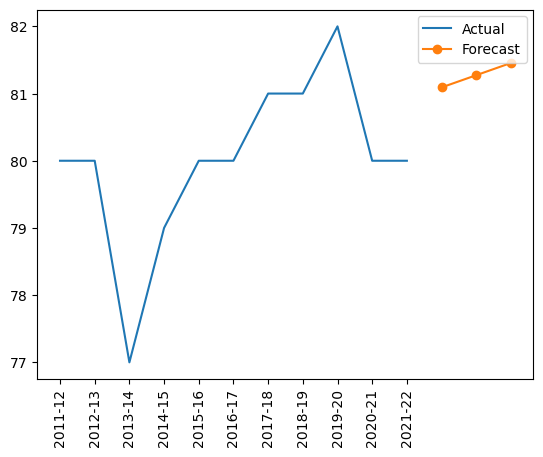

In [778]:
#Future labels..........................this didn't work, but for now it's not important to figure out why.
last_year = series.index[-1]
start_year = int(last_year.split('-')[0]) + 1
forecast_labels = [f"{start_year + i}-{start_year + i + 1 - 2000:02d}" for i in range(3)]

#Combine actual and forecast labels
all_labels = list(series.index) + forecast_labels
x_ticks = list(range(len(all_labels))) 


plt.plot(series.values, label='Actual', marker='o')

forecast_x = range(len(series), len(series) + 3)
plt.plot(forecast_x, forecast, label='Forecast', marker='o', linestyle='--')


plt.xticks(x_ticks, all_labels, rotation=90)
plt.legend()
plt.show()


In [762]:
###############################################             ETS Model

In [763]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

series = ACGR.loc["Idaho"].dropna()
model = ExponentialSmoothing(series, trend='add', seasonal=None)
model_fit = model.fit()
forecast = model_fit.forecast(steps=3)

print (forecast)

11    81.091318
12    81.273205
13    81.455092
dtype: float64


C:\Users\emcdo\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\emcdo\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\emcdo\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


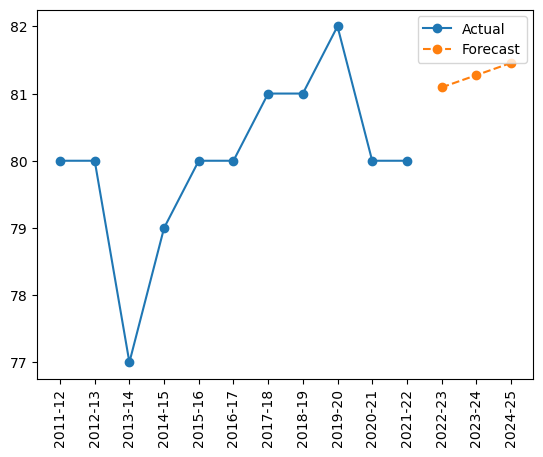

In [764]:
#Future labels
last_year = series.index[-1]
start_year = int(last_year.split('-')[0]) + 1
forecast_labels = [f"{start_year + i}-{start_year + i + 1 - 2000:02d}" for i in range(3)]

#Combine actual and forecast labels
all_labels = list(series.index) + forecast_labels
x_ticks = list(range(len(all_labels))) 


plt.plot(series.values, label='Actual', marker='o')

forecast_x = range(len(series), len(series) + 3)
plt.plot(forecast_x, forecast, label='Forecast', marker='o', linestyle='--')


plt.xticks(x_ticks, all_labels, rotation=90)
plt.legend()
plt.show()

In [765]:
###############################################            Linear Regression

In [766]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

In [767]:
df_long = ACGR.reset_index().melt(id_vars='State', var_name='Year', value_name='GradRate')
df_long['Year'] = df_long['Year'].str.slice(0, 4).astype(int)  # Convert '2011-12' → 2011

In [768]:
df_encoded = pd.get_dummies(df_long, columns=['State'], drop_first=True)

In [769]:
X = df_encoded.drop(columns='GradRate')
y = df_encoded['GradRate']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True, random_state=42)

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

rmse = mean_squared_error(y_test, y_pred, squared=False)
print("Linear Regression RMSE:", rmse)

Linear Regression RMSE: 2.0044137196024665


C:\Users\emcdo\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


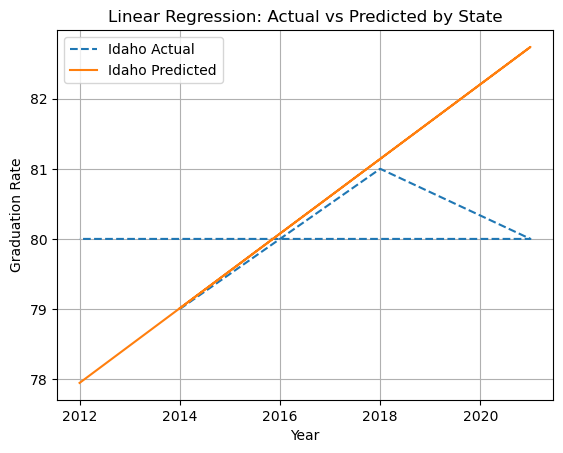

In [770]:
X_test_copy = X_test.copy()
X_test_copy['Actual'] = y_test
X_test_copy['Predicted'] = y_pred

state_cols = [col for col in X_test.columns if col.startswith('State_')]
X_test_copy['State'] = X_test[state_cols].idxmax(axis=1).str.replace('State_', '')

sample_states = ['Idaho']
X_test_copy['Year'] = X_test['Year']

for state in sample_states:
    state_df = X_test_copy[X_test_copy['State'] == state]
    plt.plot(state_df['Year'], state_df['Actual'], label=f'{state} Actual', linestyle='--')
    plt.plot(state_df['Year'], state_df['Predicted'], label=f'{state} Predicted')
plt.xlabel("Year")
plt.ylabel("Graduation Rate")
plt.title("Linear Regression: Actual vs Predicted by State")
plt.legend()
plt.grid(True)
plt.show()


In [771]:
###############################################            Random Forest Regression

In [772]:
from sklearn.ensemble import RandomForestRegressor

# Use same X_train, X_test, y_train, y_test from above
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

# Evaluate
rf_rmse = mean_squared_error(y_test, rf_pred, squared=False)
print("Random Forest RMSE:", rf_rmse)


Random Forest RMSE: 2.086397157145574


C:\Users\emcdo\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


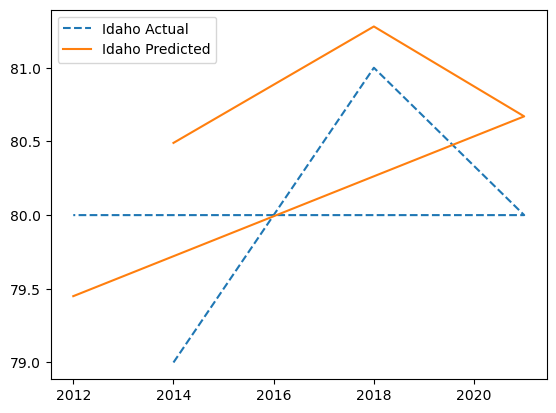

In [773]:
X_test_copy = X_test.copy()
X_test_copy['Actual'] = y_test
X_test_copy['Predicted'] = rf_pred

state_cols = [col for col in X_test.columns if col.startswith('State_')]
X_test_copy['State'] = X_test[state_cols].idxmax(axis=1).str.replace('State_', '')

X_test_copy['Year'] = X_test['Year']

sample_states = ['Idaho']
sample_df = X_test_copy[X_test_copy['State'].isin(sample_states)]

for state in sample_states:
    subset = sample_df[sample_df['State'] == state]
    plt.plot(subset['Year'], subset['Actual'], label=f'{state} Actual', linestyle='--')
    plt.plot(subset['Year'], subset['Predicted'], label=f'{state} Predicted')
plt.legend()
plt.show()

In [774]:
#These were the models I tried above:           #Yes, I know I only needed 2 or 3, but I need the practice...        
#            -ARIMA Model - handles individual state data best, and can look into the future
#            -ETS Model - Also good for future estimation, well-suited for data over time
#            -Linear Regression - Great for trendlines for multiple states simultaneously
#            -Random Forest Regression - Similar to Linear Regression, but also able to handle complex information (which this is not)

In [775]:
#Based on the results received and my understanding of each model, it seems that Linear Regression would be the best model for what I am attempting to accomplish with my capstone project;
#I don't have terribly complex information and am looking for data trends, not seasonality.